In [9]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from scripts import directed_modularity

### modularity

In [2]:
f = open('../Output/Determ/dist_nor.pckl', 'rb')
A_nor = pickle.load(f)
f.close()

In [4]:
modularity = {}; step = 15000
for p_in in A_nor.keys():
    modularity[p_in] = {}
    for p in A_nor[p_in].keys():
        modularity[p_in][p] = {}
        for k in A_nor[p_in][p].keys():
            (modularity[p_in][p][k], communitiesDict) = directed_modularity.getModularityIndex(A_nor[p_in][p][k][step])

In [6]:
fname = '../Output/Determ/dist_modul.pckl'
f = open(fname, 'wb')
pickle.dump(modularity, f)
f.close()

### Fig S4

In [7]:
f = open('../Output/Determ/dist_modul.pckl', 'rb')
dist_modularity = pickle.load(f)
f.close()

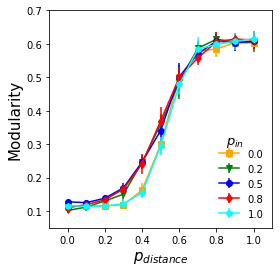

In [14]:
colorsPlot = [ 'orange', 'green','blue','red','cyan']
shapePoint = ['--s','-v','-o','-d','-h']
shapePointNoLine = ['s','v','o','d','h']
plt.rcParams['figure.figsize'] = [4, 4]

p_list = list(map(lambda x: x/10,range(11)))

for ind,p_in in enumerate(dist_modularity.keys()):
    mu_dist = []; sig_dist = []
    for p in dist_modularity[p_in].keys():
        mod_temp = []
        for k in dist_modularity[p_in][p].keys():
            mod_temp.append(dist_modularity[p_in][p][k])
        mu_dist.append(np.mean(mod_temp))
        sig_dist.append(np.std(mod_temp))
    plt.errorbar(p_list,mu_dist,sig_dist,mfc=colorsPlot[ind], mec=colorsPlot[ind], 
                         marker=shapePointNoLine[ind],
                         color=colorsPlot[ind],label = str(p_in))

plt.legend(frameon=False,loc='lower right')
plt.annotate('$p_{in}$',(0.85,0.3),fontsize=13)
plt.ylabel('Modularity',fontsize=15)
plt.xlabel('$p_{distance}$',fontsize=15)
plt.xlim([-0.1,1.1])
plt.ylim([0.05,0.7])
plt.savefig('../Output/figure/S3&4/4.eps',dpi=300, bbox_inches='tight')